In [3]:
from pathlib import Path
from zipfile import ZipFile
from io import BytesIO
import calendar
import pandas as pd
from IPython.display import display

# Find the project from a notebook opened in the project or on the Desktop.
extension_root = next(
    (folder for folder in [Path.cwd(), *Path.cwd().parents]
     if (folder / "01_data_raw").is_dir()),
    Path(r"C:\Users\manue\.codex\.chatgpt-projects\g-p-6a6dfe28cae48191a347367c8a39fae6\Who Moderates Europe")
)
extension_years = [2024, 2025, 2026]
extension_parts = []

for year in extension_years:
    for month in range(1, 6):
        period = f"{year}-{month:02d}"
        archive_path = extension_root / "01_data_raw" / f"aggregated-simple-{period}-01-parquet.zip"
        if not archive_path.is_file():
            raise FileNotFoundError(f"Missing archive: {archive_path.name}")

        with ZipFile(archive_path) as archive:
            piece_names = [name for name in archive.namelist() if name.endswith(".parquet")]
            if not piece_names:
                raise ValueError(f"No Parquet pieces in {archive_path.name}")
            for name in piece_names:
                piece = pd.read_parquet(BytesIO(archive.read(name)))
                selected = piece.loc[
                    piece["platform_name"].eq("TikTok"),
                    ["created_at", "category", "automated_decision", "count"]
                ].copy()
                selected["Month"] = period
                extension_parts.append(selected)
        print("Loaded:", period)

Loaded: 2024-01
Loaded: 2024-02
Loaded: 2024-03
Loaded: 2024-04
Loaded: 2024-05
Loaded: 2025-01
Loaded: 2025-02
Loaded: 2025-03
Loaded: 2025-04
Loaded: 2025-05
Loaded: 2026-01
Loaded: 2026-02
Loaded: 2026-03
Loaded: 2026-04
Loaded: 2026-05


In [5]:
extension_data = pd.concat(extension_parts, ignore_index=True)
print("TikTok grouped rows:", f"{len(extension_data):,}")

TikTok grouped rows: 134,048


In [7]:
extension_methods = {
    "AUTOMATED_DECISION_FULLY": "Fully automated",
    "AUTOMATED_DECISION_PARTIALLY": "Partially automated",
    "AUTOMATED_DECISION_NOT_AUTOMATED": "Non-automated"
}
extension_categories = {
    "All categories": None,
    "Illegal or harmful speech": "STATEMENT_CATEGORY_ILLEGAL_OR_HARMFUL_SPEECH",
    "Risk for public security": "STATEMENT_CATEGORY_RISK_FOR_PUBLIC_SECURITY",
    "Protection of minors": "STATEMENT_CATEGORY_PROTECTION_OF_MINORS"
}

assert not extension_data[["created_at", "category", "automated_decision", "count"]].isna().any().any(), "Missing required values"
assert extension_data["count"].gt(0).all(), "Non-positive counts"
assert extension_data["count"].mod(1).eq(0).all(), "Counts must be whole numbers"
assert set(extension_data["automated_decision"]) <= set(extension_methods), "Unexpected automation label"

extension_data["Date"] = pd.to_datetime(extension_data["created_at"], utc=True).dt.strftime("%Y-%m-%d")
extension_expected_months = {f"{year}-{month:02d}" for year in extension_years for month in range(1, 6)}
assert set(extension_data["Month"]) == extension_expected_months, "A TikTok month is absent"
extension_coverage_rows = []

for period, group in extension_data.groupby("Month"):
    year, month = map(int, period.split("-"))
    expected = set(pd.date_range(period + "-01", periods=calendar.monthrange(year, month)[1]).strftime("%Y-%m-%d"))
    present = set(group["Date"])
    assert not present - expected, f"Dates outside {period}"
    assert set(code for code in extension_categories.values() if code) <= set(group["category"]), f"Category absent in {period}"
    missing = sorted(expected - present)
    extension_coverage_rows.append({
        "Month": period,
        "Days present": len(present),
        "Days expected": len(expected),
        "Coverage gap": bool(missing),
        "Missing dates": ", ".join(missing)
    })

In [8]:
extension_coverage = pd.DataFrame(extension_coverage_rows)
display(extension_coverage)
print("Months with known day gaps:", int(extension_coverage["Coverage gap"].sum()))

,Month,Days present,Days expected,Coverage gap,Missing dates
0,2024-01,31,31,False,
1,2024-02,29,29,False,
2,2024-03,31,31,False,
3,2024-04,30,30,False,
4,2024-05,31,31,False,
5,2025-01,31,31,False,
6,2025-02,28,28,False,
7,2025-03,31,31,False,
8,2025-04,30,30,False,
9,2025-05,31,31,False,


Months with known day gaps: 0


In [9]:
extension_rows = []

for label, category_code in extension_categories.items():
    subset = extension_data if category_code is None else extension_data.loc[extension_data["category"].eq(category_code)]
    totals = subset.groupby(["Month", "automated_decision"])["count"].sum()
    for period in sorted(extension_expected_months):
        for method_code, method_label in extension_methods.items():
            extension_rows.append({
                "Year": int(period[:4]),
                "Month": period,
                "Category": label,
                "Method": method_label,
                "Count": int(totals.get((period, method_code), 0))
            })

extension_monthly_counts = pd.DataFrame(extension_rows)
extension_comparison = extension_monthly_counts.groupby(
    ["Year", "Category", "Method"], as_index=False
)["Count"].sum()
extension_totals = extension_comparison.groupby(["Year", "Category"])["Count"].transform("sum")
assert extension_totals.gt(0).all(), "A comparison has no decisions"
extension_comparison["Share %"] = 100 * extension_comparison["Count"] / extension_totals
assert extension_comparison.groupby(["Year", "Category"])["Share %"].sum().sub(100).abs().lt(0.000001).all()

extension_clean = extension_root / "02_data_clean"
extension_clean.mkdir(exist_ok=True)
extension_monthly_counts.to_csv(extension_clean / "tiktok_jan_may_2024_2026_monthly_counts.csv", index=False)
extension_comparison.to_csv(extension_clean / "tiktok_jan_may_2024_2026_comparison.csv", index=False)
extension_coverage.to_csv(extension_clean / "tiktok_jan_may_2024_2026_coverage.csv", index=False)

display(extension_comparison.pivot(index=["Category", "Year"], columns="Method", values="Share %").round(2))
print("Saved three extension tables. Stored percentages are unrounded.")

Method                          Fully automated  Non-automated  \
Category                  Year                                   
All categories            2024            93.37           6.63   
                          2025            95.60           4.40   
                          2026            92.50           7.50   
Illegal or harmful speech 2024            98.65           1.35   
                          2025            98.78           1.22   
                          2026            84.59          15.41   
Protection of minors      2024            75.06          24.94   
                          2025            39.76          60.24   
                          2026            35.02          64.98   
Risk for public security  2024             0.00         100.00   
                          2025             0.00         100.00   
                          2026             0.00         100.00   

Method                          Partially automated  
Category                  Year                       
All categories            2024                  0.0  
                          2025                  0.0  
                          2026                  0.0  
Illegal or harmful speech 2024                  0.0  
                          2025                  0.0  
                          2026                  0.0  
Protection of minors      2024                  0.0  
                          2025                  0.0  
                          2026                  0.0  
Risk for public security  2024                  0.0  
                          2025                  0.0  
                          2026                  0.0

Saved three extension tables. Stored percentages are unrounded.


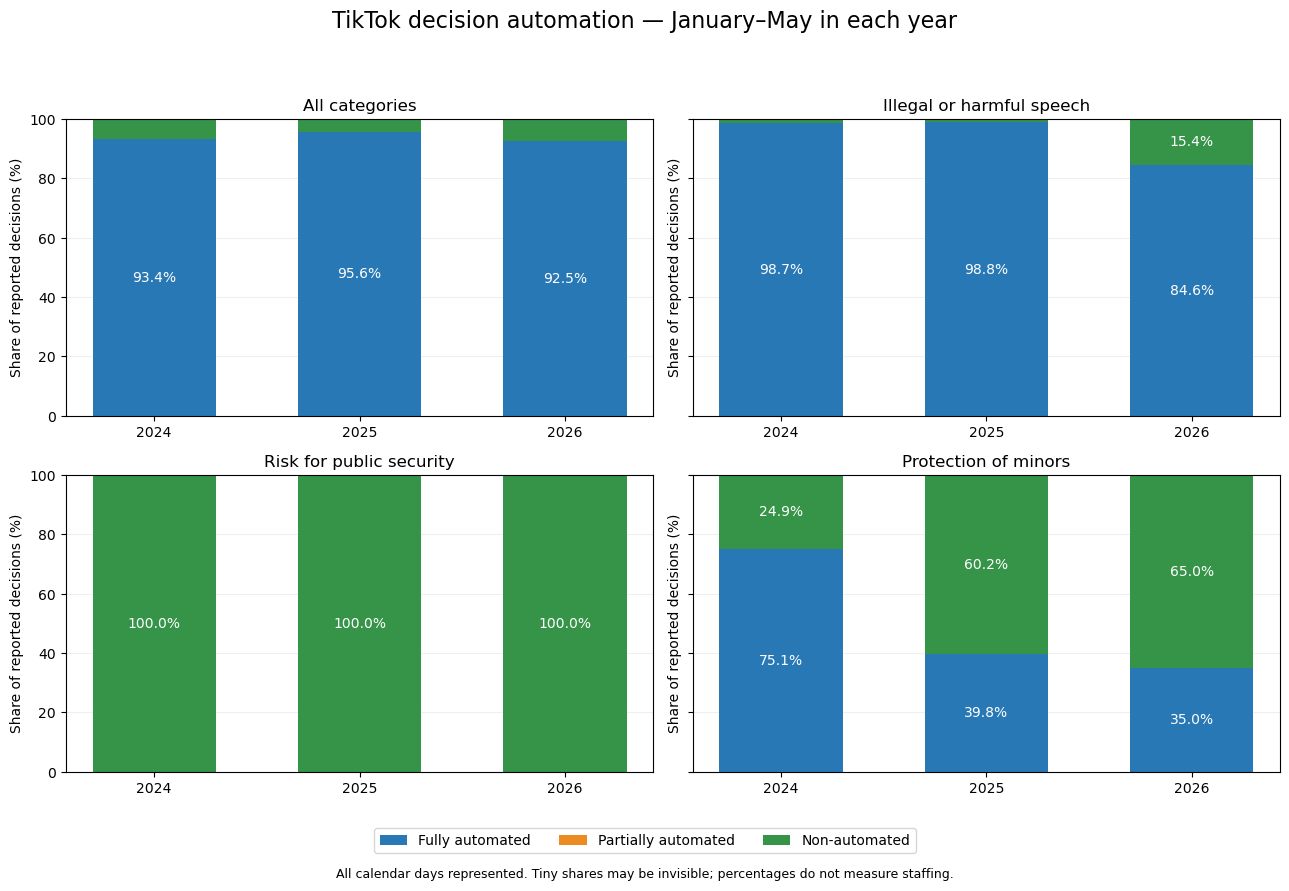

In [11]:
import matplotlib.pyplot as plt

extension_order = list(extension_methods.values())
extension_colors = ["#2878b5", "#ed8b23", "#359448"]
extension_fig, extension_axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)

for ax, category in zip(extension_axes.flat, extension_categories):
    chart_data = extension_comparison.loc[extension_comparison["Category"].eq(category)].pivot(
        index="Year", columns="Method", values="Share %"
    ).reindex(index=extension_years, columns=extension_order)
    bottom = [0.0] * len(extension_years)

    for method, color in zip(extension_order, extension_colors):
        values = chart_data[method].tolist()
        ax.bar(range(3), values, bottom=bottom, color=color, width=0.6, label=method)
        for position, (base, value) in enumerate(zip(bottom, values)):
            if value >= 10:
                ax.text(position, base + value / 2, f"{value:.1f}%", ha="center", va="center", color="white")
        bottom = [base + value for base, value in zip(bottom, values)]

    ax.set_title(category)
    ax.set_xticks(range(3), extension_years)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Share of reported decisions (%)")
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.2)

extension_fig.suptitle("TikTok decision automation — January–May in each year", fontsize=16)
handles, labels = extension_axes.flat[0].get_legend_handles_labels()
extension_fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0.035))
coverage_note = (
    "All calendar days represented."
    if not extension_coverage["Coverage gap"].any()
    else "Known day gaps: consult the coverage table."
)
extension_fig.text(0.5, 0.015, coverage_note + " Tiny shares may be invisible; percentages do not measure staffing.", ha="center", fontsize=9)
extension_fig.tight_layout(rect=[0, 0.09, 1, 0.94])
extension_dashboard = extension_root / "05_dashboard"
extension_dashboard.mkdir(exist_ok=True)
extension_fig.savefig(extension_dashboard / "tiktok_jan_may_2024_2026_notebook.png", dpi=180, bbox_inches="tight")
extension_fig.savefig(extension_dashboard / "tiktok_jan_may_2024_2026_notebook.svg", bbox_inches="tight")
plt.show()